<a href="https://colab.research.google.com/github/YYM89/MSSP607/blob/main/assignment4_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [3]:
df = pd.read_csv('/content/drive/MyDrive/MSSP607/Data/final data.csv', encoding='latin1')
display(df.head(3))

,Province,GDP,EXPAND,urbanization rate (%),population,salary,financial expenditure,CPI
0,Beijing,49843.1,49748,86.50,2183,85415,8396.48,100.1
1,Tianjin City,18024.3,35804,82.55,1364,53581,3620.68,100.2
2,Hebei Province,47526.9,24253,49.36,7378,34665,10325.97,100.2


In [4]:
df.isnull().sum()

,0
Province,0
GDP,0
EXPAND,0
urbanization rate (%),0
population,0
salary,0
financial expenditure,0
CPI,0


In [5]:
df_clean = df.dropna(subset=['EXPAND'])
print(f"\nAfter cleaning: {df_clean.shape[0]} provinces with valid EXPAND data")
expand_data = df_clean['EXPAND']


After cleaning: 31 provinces with valid EXPAND data


In [6]:
desc_stats = {
    'N': len(expand_data),
    'Mean': expand_data.mean(),
    'Median': expand_data.median(),
    'Std Dev': expand_data.std(),
    'Min': expand_data.min(),
    'Max': expand_data.max(),
    'Range': expand_data.max() - expand_data.min(),
    'CV (%)': (expand_data.std() / expand_data.mean()) * 100,
    'Q1 (25%)': expand_data.quantile(0.25),
    'Q3 (75%)': expand_data.quantile(0.75),
    'IQR': expand_data.quantile(0.75) - expand_data.quantile(0.25)
}

# Create formatted table
print("\nTable 1: Descriptive Statistics for Per Capita Consumption Expenditure (EXPAND)")
print("-" * 80)
for stat, value in desc_stats.items():
    if stat == 'N':
        print(f"{stat:<20} {int(value):>15,}")
    elif stat == 'CV (%)':
        print(f"{stat:<20} {value:>15.2f}%")
    else:
        print(f"{stat:<20} {value:>15,.2f} ¥")
print("-" * 80)

# Calculate and display confidence interval
conf_interval = stats.t.interval(0.95, len(expand_data)-1,
                                 loc=expand_data.mean(),
                                 scale=stats.sem(expand_data))
print(f"\n95% Confidence Interval for Mean: [{conf_interval[0]:,.2f}, {conf_interval[1]:,.2f}] yuan")



Table 1: Descriptive Statistics for Per Capita Consumption Expenditure (EXPAND)
--------------------------------------------------------------------------------
N                                 31
Mean                       27,690.06 ¥
Median                     24,878.00 ¥
Std Dev                     8,609.86 ¥
Min                        18,983.00 ¥
Max                        52,722.00 ¥
Range                      33,739.00 ¥
CV (%)                         31.09%
Q1 (25%)                   22,118.00 ¥
Q3 (75%)                   28,000.50 ¥
IQR                         5,882.50 ¥
--------------------------------------------------------------------------------

95% Confidence Interval for Mean: [24,531.94, 30,848.19] yuan


In [7]:
print("\n" + "=" * 80)
print("QUESTION 2: NORMALITY TESTING")
print("=" * 80)

# Shapiro-Wilk test (preferred for small samples)
shapiro_stat, shapiro_p = stats.shapiro(expand_data)

# Kolmogorov-Smirnov test
ks_stat, ks_p = stats.kstest(expand_data, 'norm',
                              args=(expand_data.mean(), expand_data.std()))

# Anderson-Darling test
anderson_result = stats.anderson(expand_data)

# Skewness and Kurtosis
skewness = stats.skew(expand_data)
kurtosis = stats.kurtosis(expand_data)

print("\nTable 2: Normality Test Results")
print("-" * 80)
print(f"{'Test':<30} {'Statistic':<15} {'p-value':<15} {'Result':<20}")
print("-" * 80)
print(f"{'Shapiro-Wilk':<30} {shapiro_stat:<15.4f} {shapiro_p:<15.4f} "
      f"{'Normal' if shapiro_p > 0.05 else 'Not Normal':<20}")
print(f"{'Kolmogorov-Smirnov':<30} {ks_stat:<15.4f} {ks_p:<15.4f} "
      f"{'Normal' if ks_p > 0.05 else 'Not Normal':<20}")
print("-" * 80)
print(f"\nSkewness: {skewness:.4f} (>0 indicates right skew)")
print(f"Kurtosis: {kurtosis:.4f} (>0 indicates heavy tails)")
print(f"\nAnderson-Darling Critical Values (significance level):")
for i, sl in enumerate([15, 10, 5, 2.5, 1]):
    result = "Reject normality" if anderson_result.statistic > anderson_result.critical_values[i] else "Fail to reject"
    print(f"  {sl}%: {anderson_result.critical_values[i]:.3f} ({result})")



QUESTION 2: NORMALITY TESTING

Table 2: Normality Test Results
--------------------------------------------------------------------------------
Test                           Statistic       p-value         Result              
--------------------------------------------------------------------------------
Shapiro-Wilk                   0.7852          0.0000          Not Normal          
Kolmogorov-Smirnov             0.2546          0.0293          Not Normal          
--------------------------------------------------------------------------------

Skewness: 1.6195 (>0 indicates right skew)
Kurtosis: 1.7830 (>0 indicates heavy tails)

Anderson-Darling Critical Values (significance level):
  15%: 0.522 (Reject normality)
  10%: 0.595 (Reject normality)
  5%: 0.713 (Reject normality)
  2.5%: 0.832 (Reject normality)
  1%: 0.990 (Reject normality)


In [8]:
# 4. OUTLIER DETECTION
# ============================================================================

print("\n" + "=" * 80)
print("QUESTION 4: OUTLIER IDENTIFICATION")
print("=" * 80)

# Method 1: IQR method
Q1 = expand_data.quantile(0.25)
Q3 = expand_data.quantile(0.75)
IQR = Q3 - Q1
lower_bound_iqr = Q1 - 1.5 * IQR
upper_bound_iqr = Q3 + 1.5 * IQR

outliers_iqr = expand_data[(expand_data < lower_bound_iqr) | (expand_data > upper_bound_iqr)]

# Method 2: Z-score method (|z| > 3)
z_scores = np.abs(stats.zscore(expand_data))
outliers_zscore = expand_data[z_scores > 3]

# Method 3: Modified Z-score (MAD-based, robust)
median = expand_data.median()
mad = np.median(np.abs(expand_data - median))
modified_z_scores = 0.6745 * (expand_data - median) / mad
outliers_modified_z = expand_data[np.abs(modified_z_scores) > 3.5]

print("\nTable 3: Outlier Detection Results")
print("-" * 80)
print(f"{'Method':<30} {'Outliers Found':<20} {'Outlier Values':<30}")
print("-" * 80)
print(f"{'IQR Method (1.5×IQR)':<30} {len(outliers_iqr):<20} "
      f"{', '.join([f'{x:.0f}' for x in outliers_iqr]) if len(outliers_iqr) > 0 else 'None'}")
print(f"{'Z-Score Method (|z| > 3)':<30} {len(outliers_zscore):<20} "
      f"{', '.join([f'{x:.0f}' for x in outliers_zscore]) if len(outliers_zscore) > 0 else 'None'}")
print(f"{'Modified Z-Score (>3.5)':<30} {len(outliers_modified_z):<20} "
      f"{', '.join([f'{x:.0f}' for x in outliers_modified_z]) if len(outliers_modified_z) > 0 else 'None'}")
print("-" * 80)

if len(outliers_iqr) > 0:
    print(f"\nIQR Boundaries:")
    print(f"  Lower fence: {lower_bound_iqr:,.2f} yuan")
    print(f"  Upper fence: {upper_bound_iqr:,.2f} yuan")

    # Identify which provinces are outliers
    outlier_provinces = df_clean[df_clean['EXPAND'].isin(outliers_iqr)][['Province', 'EXPAND']]
    print(f"\nOutlier Provinces (IQR Method):")
    for _, row in outlier_provinces.iterrows():
        print(f"  {row['Province']}: {float(row['EXPAND']):,.2f} yuan")


QUESTION 4: OUTLIER IDENTIFICATION

Table 3: Outlier Detection Results
--------------------------------------------------------------------------------
Method                         Outliers Found       Outlier Values                
--------------------------------------------------------------------------------
IQR Method (1.5×IQR)           4                    49748, 52722, 37346, 45107
Z-Score Method (|z| > 3)       0                    None
Modified Z-Score (>3.5)        3                    49748, 52722, 45107
--------------------------------------------------------------------------------

IQR Boundaries:
  Lower fence: 13,294.25 yuan
  Upper fence: 36,824.25 yuan

Outlier Provinces (IQR Method):
  Beijing: 49,748.00 yuan
  Shanghai: 52,722.00 yuan
  Jiangsu Province: 37,346.00 yuan
  Zhejiang Province: 45,107.00 yuan



QUESTION 3: CREATING VISUALIZATIONS


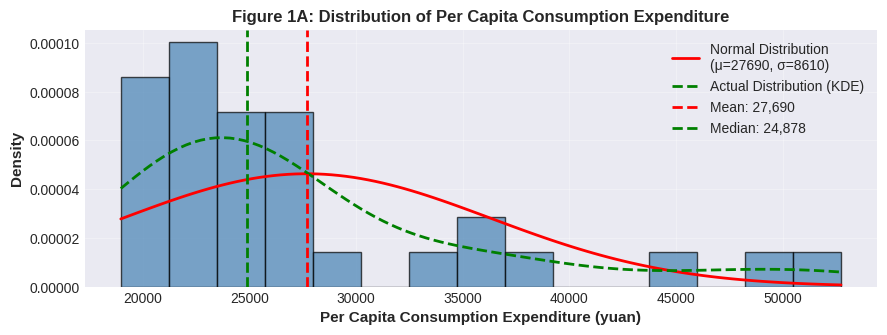

In [9]:
print("\n" + "=" * 80)
print("QUESTION 3: CREATING VISUALIZATIONS")
print("=" * 80)

fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Histogram with density curve
ax1 = fig.add_subplot(gs[0, :2])
n, bins, patches = ax1.hist(expand_data, bins=15, density=True,
                            alpha=0.7, color='steelblue', edgecolor='black')
# Add normal distribution curve
mu, sigma = expand_data.mean(), expand_data.std()
x = np.linspace(expand_data.min(), expand_data.max(), 100)
ax1.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2,
         label=f'Normal Distribution\n(μ={mu:.0f}, σ={sigma:.0f})')
# Add actual kernel density
from scipy.stats import gaussian_kde
kde = gaussian_kde(expand_data)
ax1.plot(x, kde(x), 'g--', linewidth=2, label='Actual Distribution (KDE)')
ax1.axvline(expand_data.mean(), color='red', linestyle='--', linewidth=2,
            label=f'Mean: {expand_data.mean():,.0f}')
ax1.axvline(expand_data.median(), color='green', linestyle='--', linewidth=2,
            label=f'Median: {expand_data.median():,.0f}')
ax1.set_xlabel('Per Capita Consumption Expenditure (yuan)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Density', fontsize=11, fontweight='bold')
ax1.set_title('Figure 1A: Distribution of Per Capita Consumption Expenditure',
              fontsize=12, fontweight='bold')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

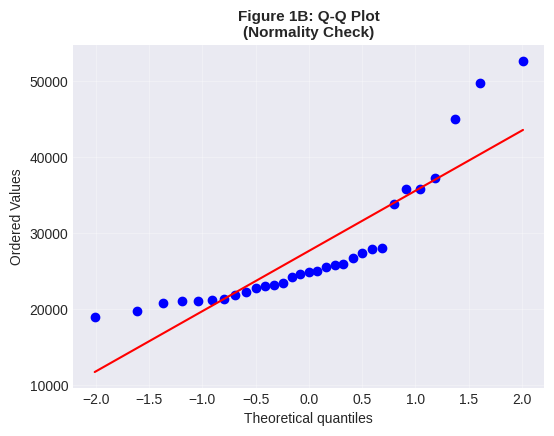

In [10]:
# 2. Q-Q Plot
fig = plt.figure(figsize=(16,12))
gs = fig.add_gridspec(3, 3)
ax2 = fig.add_subplot(gs[0, 2])
stats.probplot(expand_data, dist="norm", plot=ax2)
ax2.set_title('Figure 1B: Q-Q Plot\n(Normality Check)', fontsize=11, fontweight='bold')
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

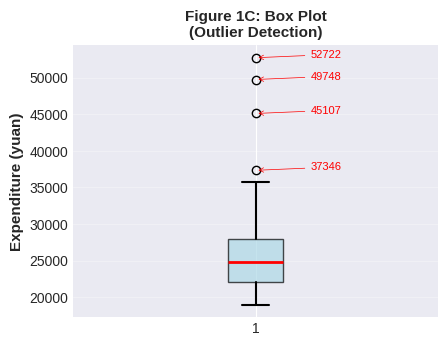

In [11]:
# 3. Box Plot with outlier annotations
fig = plt.figure(figsize=(16,12))
gs = fig.add_gridspec(3, 3)
ax3 = fig.add_subplot(gs[1, 0])
bp = ax3.boxplot(expand_data, vert=True, patch_artist=True,
                 boxprops=dict(facecolor='lightblue', alpha=0.7),
                 medianprops=dict(color='red', linewidth=2),
                 whiskerprops=dict(linewidth=1.5),
                 capprops=dict(linewidth=1.5))
ax3.set_ylabel('Expenditure (yuan)', fontsize=11, fontweight='bold')
ax3.set_title('Figure 1C: Box Plot\n(Outlier Detection)', fontsize=11, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')
# Add outlier labels
if len(outliers_iqr) > 0:
    for outlier in outliers_iqr:
        ax3.annotate(f'{outlier:.0f}', xy=(1, outlier), xytext=(1.15, outlier),
                    fontsize=8, ha='left', color='red',
                    arrowprops=dict(arrowstyle='->', color='red', lw=0.5))
plt.show()

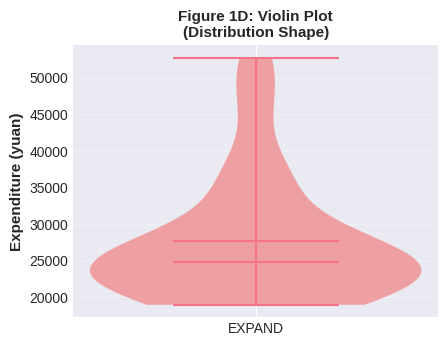

In [12]:
# 4. Violin Plot
fig = plt.figure(figsize=(16,12))
gs = fig.add_gridspec(3, 3)
ax4 = fig.add_subplot(gs[1, 1])
parts = ax4.violinplot([expand_data], positions=[1], showmeans=True, showmedians=True)
for pc in parts['bodies']:
    pc.set_facecolor('lightcoral')
    pc.set_alpha(0.7)
ax4.set_ylabel('Expenditure (yuan)', fontsize=11, fontweight='bold')
ax4.set_title('Figure 1D: Violin Plot\n(Distribution Shape)', fontsize=11, fontweight='bold')
ax4.set_xticks([1])
ax4.set_xticklabels(['EXPAND'])
ax4.grid(True, alpha=0.3, axis='y')
plt.show()

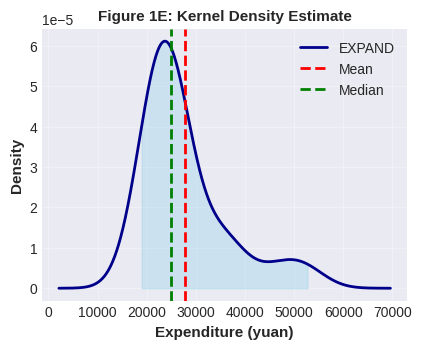

In [13]:
# 5. Kernel Density Estimate
fig = plt.figure(figsize=(16,12))
gs = fig.add_gridspec(3, 3)
ax5 = fig.add_subplot(gs[1, 2])
expand_data.plot(kind='kde', ax=ax5, linewidth=2, color='darkblue')
ax5.fill_between(x, kde(x), alpha=0.3, color='skyblue')
ax5.axvline(expand_data.mean(), color='red', linestyle='--',
            linewidth=2, label='Mean')
ax5.axvline(expand_data.median(), color='green', linestyle='--',
            linewidth=2, label='Median')
ax5.set_xlabel('Expenditure (yuan)', fontsize=11, fontweight='bold')
ax5.set_ylabel('Density', fontsize=11, fontweight='bold')
ax5.set_title('Figure 1E: Kernel Density Estimate', fontsize=11, fontweight='bold')
ax5.legend()
ax5.grid(True, alpha=0.3)
plt.show()

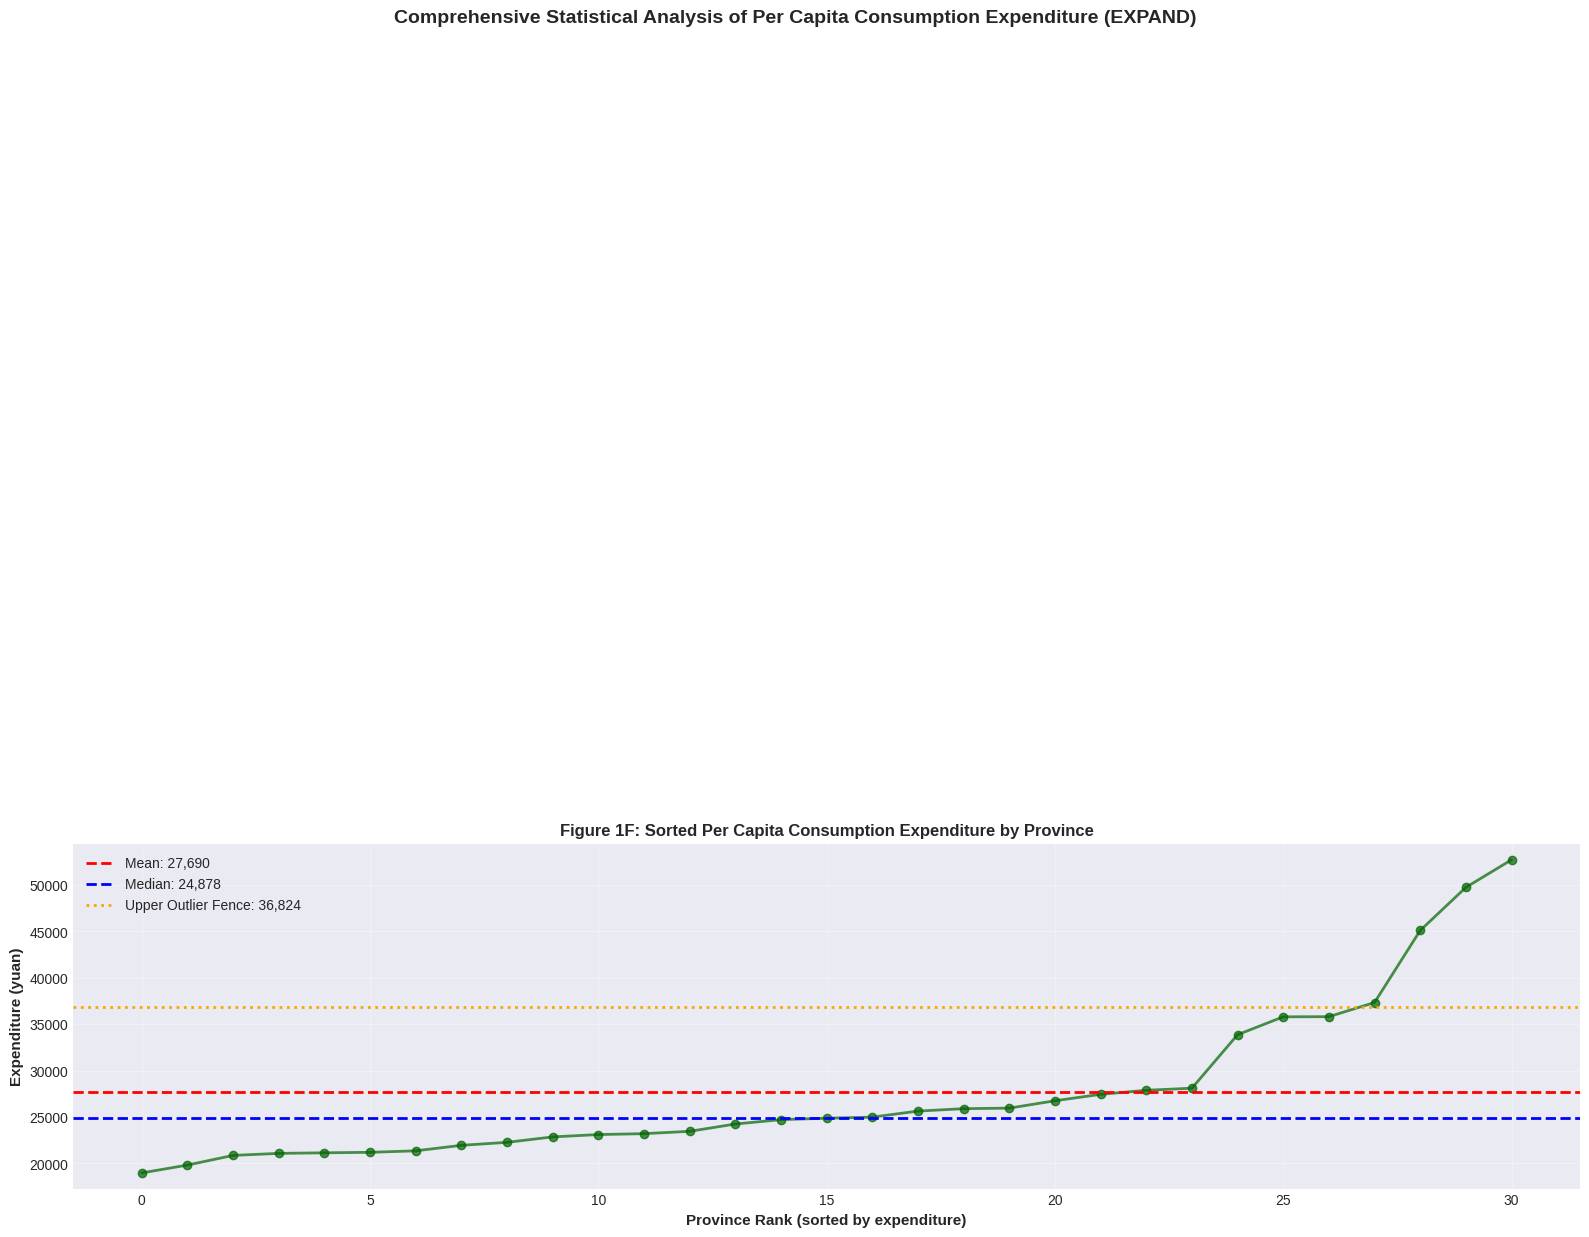

In [14]:
# 6. Sorted values plot (to visualize distribution pattern)
fig = plt.figure(figsize=(16, 16))
gs = fig.add_gridspec(4, 1)
ax6 = fig.add_subplot(gs[2, :])
sorted_expand = np.sort(expand_data)
ax6.plot(range(len(sorted_expand)), sorted_expand, 'o-', linewidth=2,
         markersize=6, color='darkgreen', alpha=0.7)
ax6.axhline(expand_data.mean(), color='red', linestyle='--',
            linewidth=2, label=f'Mean: {expand_data.mean():,.0f}')
ax6.axhline(expand_data.median(), color='blue', linestyle='--',
            linewidth=2, label=f'Median: {expand_data.median():,.0f}')
if len(outliers_iqr) > 0:
    ax6.axhline(upper_bound_iqr, color='orange', linestyle=':',
                linewidth=2, label=f'Upper Outlier Fence: {upper_bound_iqr:,.0f}')
ax6.set_xlabel('Province Rank (sorted by expenditure)', fontsize=11, fontweight='bold')
ax6.set_ylabel('Expenditure (yuan)', fontsize=11, fontweight='bold')
ax6.set_title('Figure 1F: Sorted Per Capita Consumption Expenditure by Province',
              fontsize=12, fontweight='bold')
ax6.legend(loc='upper left')
ax6.grid(True, alpha=0.3)

plt.suptitle('Comprehensive Statistical Analysis of Per Capita Consumption Expenditure (EXPAND)',
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

In [15]:
print("\n" + "=" * 80)
print("QUESTION 5: ADDITIONAL PATTERNS AND INSIGHTS")
print("=" * 80)

# Regional analysis if province names are available
print("\nRegional Distribution Analysis:")
print("-" * 80)

# Calculate percentiles for categorization
p33 = expand_data.quantile(0.33)
p67 = expand_data.quantile(0.67)

df_clean['Category'] = pd.cut(df_clean['EXPAND'].astype(float),
                               bins=[0, p33, p67, np.inf],
                               labels=['Low', 'Medium', 'High'])

category_summary = df_clean.groupby('Category')['EXPAND'].agg([
    ('Count', 'count'),
    ('Mean', 'mean'),
    ('Std', 'std'),
    ('Min', 'min'),
    ('Max', 'max')
])

print(category_summary)



QUESTION 5: ADDITIONAL PATTERNS AND INSIGHTS

Regional Distribution Analysis:
--------------------------------------------------------------------------------
          Count          Mean          Std    Min    Max
Category                                                
Low          10  21159.200000  1127.336960  18983  22865
Medium       11  24811.545455  1208.642161  23118  26760
High         10  37387.300000  9066.504717  27451  52722


In [16]:
# Top 5 and Bottom 5 provinces
print("\nTop 5 Provinces (Highest Consumption):")
print("-" * 80)
top5 = df_clean.nlargest(5, 'EXPAND')[['Province', 'EXPAND']]
for i, (_, row) in enumerate(top5.iterrows(), 1):
    print(f"{i}. {row['Province']}: {float(row['EXPAND']):,.2f} yuan")

print("\nBottom 5 Provinces (Lowest Consumption):")
print("-" * 80)
bottom5 = df_clean.nsmallest(5, 'EXPAND')[['Province', 'EXPAND']]
for i, (_, row) in enumerate(bottom5.iterrows(), 1):
    print(f"{i}. {row['Province']}: {float(row['EXPAND']):,.2f} yuan")

# Coefficient of Variation interpretation
print(f"\nVariability Analysis:")
print("-" * 80)
cv = (expand_data.std() / expand_data.mean()) * 100
print(f"Coefficient of Variation: {cv:.2f}%")
if cv < 15:
    variability = "low variability"
elif cv < 30:
    variability = "moderate variability"
else:
    variability = "high variability"
print(f"Interpretation: The data exhibits {variability} across provinces.")

# Range analysis
range_val = expand_data.max() - expand_data.min()
range_pct = (range_val / expand_data.mean()) * 100
print(f"\nRange: {range_val:,.2f} yuan ({range_pct:.1f}% of mean)")
print(f"This indicates {'substantial' if range_pct > 100 else 'moderate'} "
      f"disparity in consumption levels across provinces.")

print("\n" + "=" * 80)
print("ANALYSIS COMPLETE")
print("=" * 80)
print("\nOutput files generated:")
print("1. expand_analysis_comprehensive.png - Comprehensive visualization")
print("2. Console output - Detailed statistical analysis")


Top 5 Provinces (Highest Consumption):
--------------------------------------------------------------------------------
1. Shanghai: 52,722.00 yuan
2. Beijing: 49,748.00 yuan
3. Zhejiang Province: 45,107.00 yuan
4. Jiangsu Province: 37,346.00 yuan
5. Guangdong Province: 35,818.00 yuan

Bottom 5 Provinces (Lowest Consumption):
--------------------------------------------------------------------------------
1. Tibet Autonomous Region: 18,983.00 yuan
2. Gansu Province: 19,829.00 yuan
3. Guizhou Province: 20,871.00 yuan
4. Shanxi Province: 21,090.00 yuan
5. Guangxi Zhuang Autonomous Region: 21,150.00 yuan

Variability Analysis:
--------------------------------------------------------------------------------
Coefficient of Variation: 31.09%
Interpretation: The data exhibits high variability across provinces.

Range: 33,739.00 yuan (121.8% of mean)
This indicates substantial disparity in consumption levels across provinces.

ANALYSIS COMPLETE

Output files generated:
1. expand_analysis_comp